# Bloc 4 — Analyse Prédictive de Données Non-Structurées par l'IA
## FEM Surrogate ML — RNCP Référentiel

| Compétence | Description |
|---|---|
| C4.1 | Traitement des images → tenseurs interprétables par un réseau de neurones profond |
| C4.2 | CNN convolutif from scratch (Conv2D, MaxPooling, Dropout) via TensorFlow/Keras |
| C4.3 | Transfer learning — MobileNetV2 pré-entraîné sur ImageNet |
| C4.4 | Augmentation des données (rotation, flip, zoom) pour enrichir la base d'entraînement |
| C4.5 | Évaluation : accuracy, loss, matrice de confusion, rapport de classification |

---
## Fiche Livrable — RNCP Bloc 4

**Type d'évaluation :** Étude de cas pratique sur des données non-structurées

**Données :** 51 550 images PNG 64×64 px — champs de contrainte Von Mises (solution de Kirsch)  
générées au Bloc 3 depuis les paramètres physiques des simulations FEM

**Problématique :** Peut-on entraîner un réseau de neurones convolutif à **identifier automatiquement
le type de géométrie** d'une plaque métallique (trou fixe / sans trou / trou mobile)
à partir de son image de champ de contrainte ?

**Classes :**
- `with_hole` — plaque avec trou centré
- `without_hole` — plaque sans trou (traction uniforme)
- `with_hole_moving` — plaque avec trou décentré

**Critères d'évaluation :**
- Qualité de préparation des données (tenseurs, normalisation, augmentation)
- Pertinence du choix du réseau de neurones (convolutif)
- Efficacité mesurée par accuracy et loss sur données de validation
- Clarté de la détection des signaux dans les images
- Comparaison CNN scratch vs transfer learning

---

In [1]:
import os
import warnings
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

ROOT      = pathlib.Path('..')
IMG_DIR   = ROOT / 'data' / 'unstructured' / 'images'
MANIFEST  = ROOT / 'data' / 'unstructured' / 'manifest.csv'

IMG_SIZE  = (64, 64)
BATCH     = 64
CLASSES   = ['with_hole', 'with_hole_moving', 'without_hole']
N_CLASSES = len(CLASSES)
SEED      = 42

print(f'TensorFlow : {tf.__version__}')
print(f'GPU disponible : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Classes : {CLASSES}')

TensorFlow : 2.21.0
GPU disponible : False
Classes : ['with_hole', 'with_hole_moving', 'without_hole']


---
# 1. Préparation des données — Tenseurs (C4.1)

Les images PNG 64×64 sont chargées via `image_dataset_from_directory` de Keras.
Chaque image est convertie en **tenseur** de forme `(64, 64, 3)` (hauteur × largeur × canaux RGB).
Les pixels sont normalisés entre 0 et 1 (division par 255).

In [2]:
def make_dataset(split: str, shuffle: bool = False) -> tf.data.Dataset:
    ds = tf.keras.utils.image_dataset_from_directory(
        str(IMG_DIR / split),
        image_size=IMG_SIZE,
        batch_size=BATCH,
        shuffle=shuffle,
        seed=SEED,
        class_names=CLASSES,
        label_mode='categorical',
    )
    # Normalisation [0, 255] → [0, 1]
    return ds.map(lambda x, y: (x / 255.0, y),
                  num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

ds_train = make_dataset('train', shuffle=True)
ds_val   = make_dataset('val')
ds_test  = make_dataset('test')

# Vérification des tenseurs
for images, labels in ds_train.take(1):
    print(f'Batch images : {images.shape}  dtype={images.dtype}')
    print(f'Batch labels : {labels.shape}  dtype={labels.dtype}')
    print(f'Pixels min={images.numpy().min():.3f}  max={images.numpy().max():.3f}')
    print(f'Label exemple : {labels[0].numpy()} → {CLASSES[labels[0].numpy().argmax()]}')

Found 36086 files belonging to 3 classes.
Found 7758 files belonging to 3 classes.
Found 7706 files belonging to 3 classes.
Batch images : (64, 64, 64, 3)  dtype=<dtype: 'float32'>
Batch labels : (64, 3)  dtype=<dtype: 'float32'>
Pixels min=0.000  max=1.000
Label exemple : [0. 1. 0.] → with_hole_moving


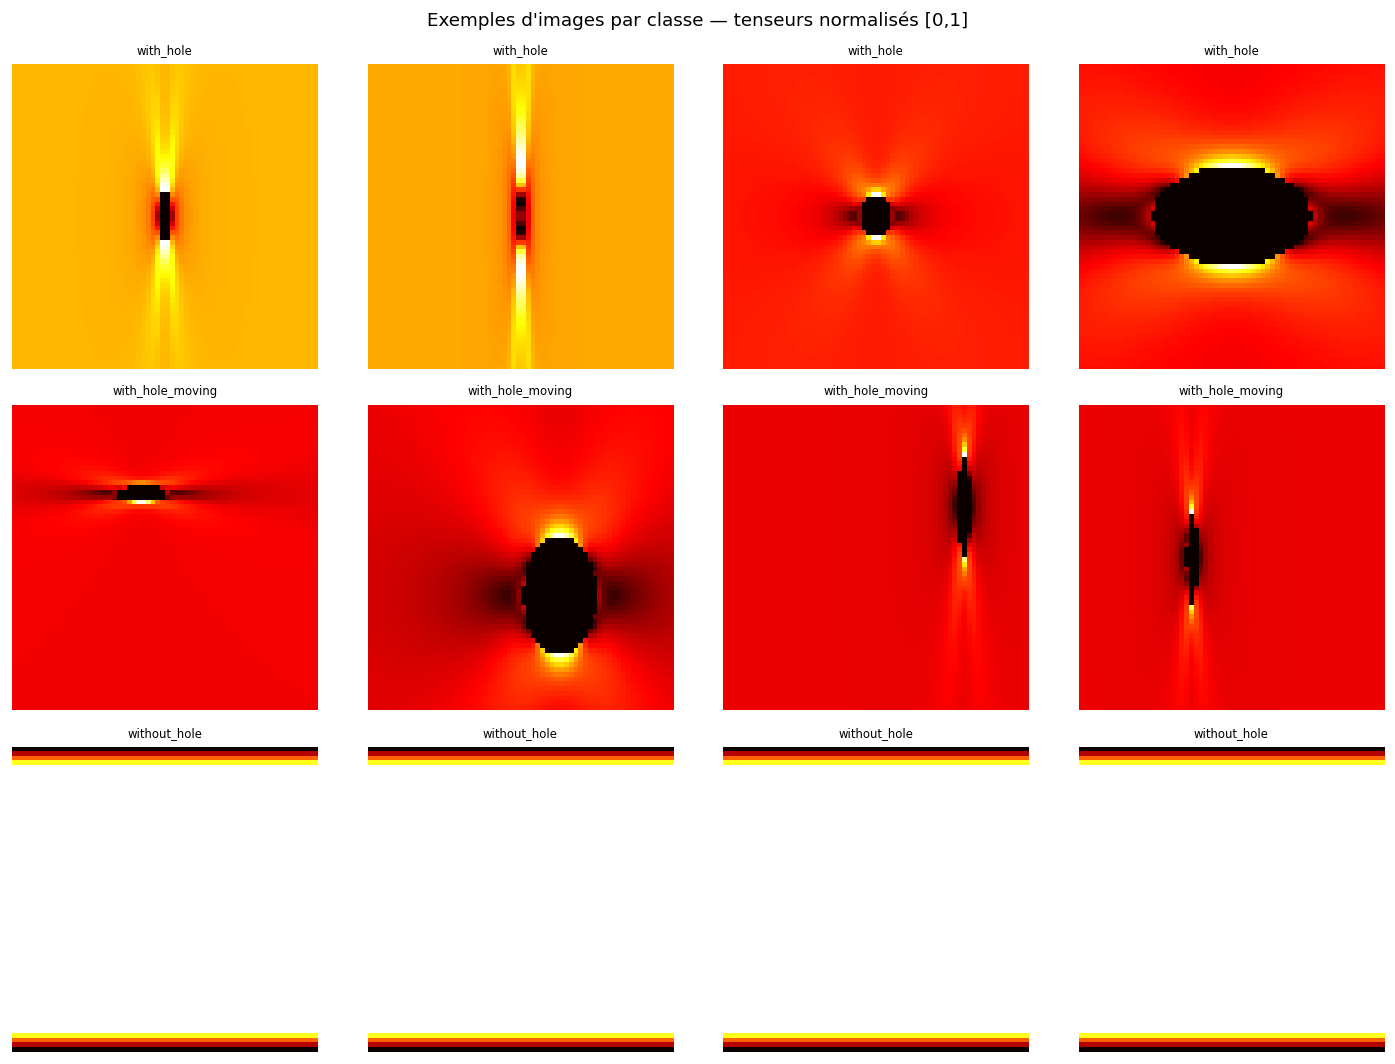

In [3]:
# Afficher des exemples par classe
fig, axes = plt.subplots(N_CLASSES, 4, figsize=(12, 3 * N_CLASSES))

for images, labels in ds_train.take(1):
    for class_idx, class_name in enumerate(CLASSES):
        class_mask = labels.numpy().argmax(axis=1) == class_idx
        class_imgs = images.numpy()[class_mask][:4]
        for j, img in enumerate(class_imgs):
            axes[class_idx][j].imshow(img)
            axes[class_idx][j].set_title(f'{class_name}', fontsize=7)
            axes[class_idx][j].axis('off')

plt.suptitle('Exemples d\'images par classe — tenseurs normalisés [0,1]', fontsize=11)
plt.tight_layout()
plt.show()

---
# 2. Augmentation des Données (C4.4)

L'augmentation crée des **variantes artificielles** des images d'entraînement
pour améliorer la généralisation et réduire le sur-entraînement.

Transformations appliquées :
- **Flip horizontal / vertical** — symétries physiquement cohérentes
- **Rotation aléatoire** — ±10% (≈ 36°)
- **Zoom aléatoire** — ±10%
- **Translation** — ±10% horizontale et verticale

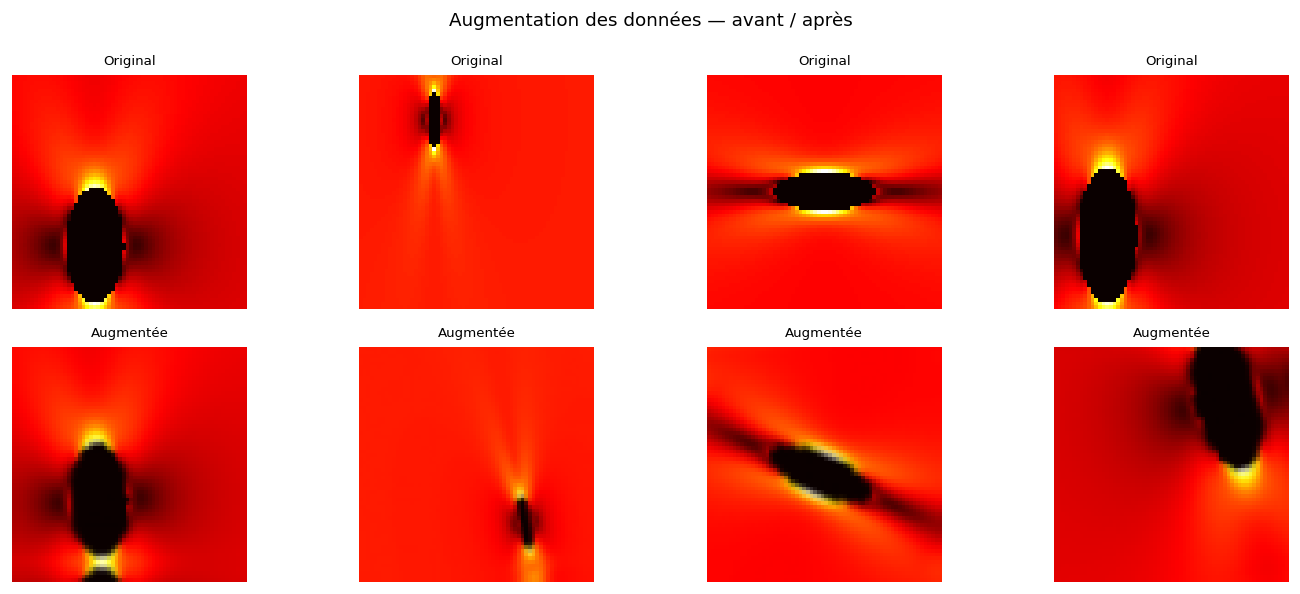

Dataset augmenté prêt.


In [4]:
augmentation = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10),
], name='augmentation')

# Visualisation avant / après augmentation
for images, _ in ds_train.take(1):
    sample = images[:4]
    augmented = augmentation(sample, training=True)

fig, axes = plt.subplots(2, 4, figsize=(12, 5))
for j in range(4):
    axes[0][j].imshow(sample[j].numpy())
    axes[0][j].set_title('Original', fontsize=8)
    axes[0][j].axis('off')
    axes[1][j].imshow(augmented[j].numpy())
    axes[1][j].set_title('Augmentée', fontsize=8)
    axes[1][j].axis('off')

plt.suptitle('Augmentation des données — avant / après', fontsize=11)
plt.tight_layout()
plt.show()

# Dataset augmenté
ds_train_aug = ds_train.map(
    lambda x, y: (augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print('Dataset augmenté prêt.')

---
# 3. CNN from Scratch (C4.2)

Architecture convolutive classique :
- **Blocs Conv2D + MaxPooling** — extraction des features locales (bords, textures, formes)
- **BatchNormalization** — stabilise l'entraînement
- **Dropout** — régularisation contre le sur-entraînement
- **Dense final** — classification softmax sur 3 classes

In [5]:
def build_cnn(input_shape=(64, 64, 3), n_classes=3):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inp, out, name='CNN_scratch')

cnn = build_cnn()
cnn.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
cnn.summary()

Model: "CNN_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,939 (499.76 KB)

 Trainable params: 127,491 (498.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [6]:
callbacks_cnn = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                  monitor='val_accuracy', verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3,
                                       monitor='val_loss', verbose=1),
]

print('Entraînement CNN from scratch...')
hist_cnn = cnn.fit(
    ds_train_aug,
    validation_data=ds_val,
    epochs=30,
    callbacks=callbacks_cnn,
    verbose=1,
)

Entraînement CNN from scratch...
Epoch 1/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.8865 - loss: 0.2549 - val_accuracy: 0.7363 - val_loss: 0.7422 - learning_rate: 0.0010
Epoch 2/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 84s 148ms/step - accuracy: 0.9525 - loss: 0.1250 - val_accuracy: 0.8253 - val_loss: 0.5428 - learning_rate: 0.0010
Epoch 3/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 86s 152ms/step - accuracy: 0.9624 - loss: 0.1008 - val_accuracy: 0.7577 - val_loss: 0.9208 - learning_rate: 0.0010
Epoch 4/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 85s 151ms/step - accuracy: 0.9661 - loss: 0.0920 - val_accuracy: 0.9389 - val_loss: 0.1736 - learning_rate: 0.0010
Epoch 5/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 87s 154ms/step - accuracy: 0.9698 - loss: 0.0821 - val_accuracy: 0.9359 - val_loss: 0.1604 - learning_rate: 0.0010
Epoch 6/30
564/564 ━━━━━━━━━━━━━━━━━━━━ 89s 157ms/step - accuracy: 0.9725 - loss: 0.0775 - val_accuracy: 0.9447 - val_loss: 0.1632 - learning_rate: 0.0010
Epoch 7/30
564/564 ━━━━━━━━━━━━━━━━━━

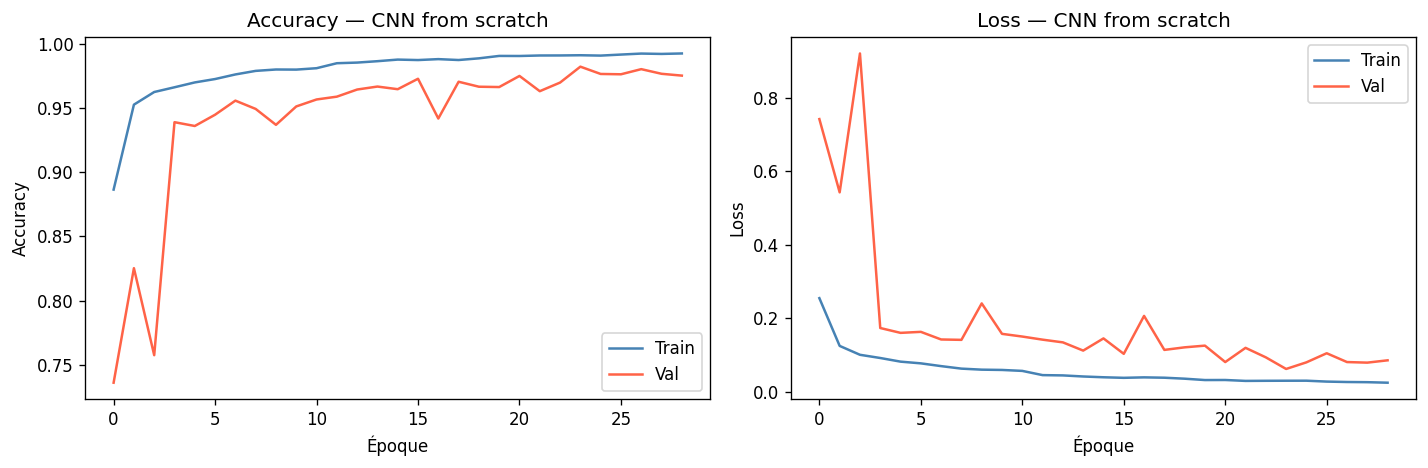

Test — Loss: 0.0536  Accuracy: 0.9846 (98.5%)


In [7]:
def plot_history(hist, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric, label in zip(axes, ['accuracy', 'loss'], ['Accuracy', 'Loss']):
        ax.plot(hist.history[metric],     label='Train', color='steelblue')
        ax.plot(hist.history[f'val_{metric}'], label='Val',   color='tomato')
        ax.set_title(f'{label} — {title}')
        ax.set_xlabel('Époque')
        ax.set_ylabel(label)
        ax.legend()
    plt.tight_layout()
    plt.show()

plot_history(hist_cnn, 'CNN from scratch')

loss_cnn, acc_cnn = cnn.evaluate(ds_test, verbose=0)
print(f'Test — Loss: {loss_cnn:.4f}  Accuracy: {acc_cnn:.4f} ({acc_cnn*100:.1f}%)')

---
# 4. Transfer Learning — MobileNetV2 (C4.3)

**MobileNetV2** est un réseau pré-entraîné sur **ImageNet** (1,2M images, 1000 classes).
On exploite ses features génériques (bords, textures) et on remplace uniquement la tête de classification.

**Stratégie en 2 phases :**
1. **Phase 1** — base MobileNetV2 gelée (`trainable=False`) → entraîner uniquement la tête
2. **Phase 2** — fine-tuning : dégeler les dernières couches pour affiner les features

In [8]:
def build_transfer(input_shape=(64, 64, 3), n_classes=3):
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape,
    )
    base.trainable = False  # Phase 1 : base gelée

    inp = keras.Input(shape=input_shape)
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(128, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)

    return keras.Model(inp, out, name='MobileNetV2_transfer'), base

tl_model, base_model = build_transfer()
tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Paramètres totaux     : {tl_model.count_params():,}')
print(f'Paramètres entraînables : {sum(p.numpy().size for p in tl_model.trainable_weights):,}')
print(f'Base MobileNetV2 gelée : {not base_model.trainable}')

Paramètres totaux     : 2,422,339
Paramètres entraînables : 164,355
Base MobileNetV2 gelée : True


In [9]:
callbacks_tl = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True,
                                  monitor='val_accuracy', verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
]

print('Phase 1 — Entraînement de la tête (base gelée)...')
hist_tl1 = tl_model.fit(
    ds_train_aug,
    validation_data=ds_val,
    epochs=15,
    callbacks=callbacks_tl,
    verbose=1,
)

Phase 1 — Entraînement de la tête (base gelée)...
Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 46s 78ms/step - accuracy: 0.9156 - loss: 0.2138 - val_accuracy: 0.9140 - val_loss: 0.2046 - learning_rate: 0.0010
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 45s 79ms/step - accuracy: 0.9409 - loss: 0.1562 - val_accuracy: 0.9145 - val_loss: 0.2305 - learning_rate: 0.0010
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 47s 82ms/step - accuracy: 0.9446 - loss: 0.1488 - val_accuracy: 0.9295 - val_loss: 0.1762 - learning_rate: 0.0010
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 47s 82ms/step - accuracy: 0.9483 - loss: 0.1399 - val_accuracy: 0.9344 - val_loss: 0.1731 - learning_rate: 0.0010
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 46s 81ms/step - accuracy: 0.9498 - loss: 0.1360 - val_accuracy: 0.9163 - val_loss: 0.2358 - learning_rate: 0.0010
Epoch 6/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 47s 83ms/step - accuracy: 0.9521 - loss: 0.1307 - val_accuracy: 0.9247 - val_loss: 0.1948 - learning_rate: 0.0010
Epoch 7/15
564/564 ━━━━━━━

In [10]:
# Phase 2 — Fine-tuning : dégeler les 30 dernières couches
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

tl_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),  # LR plus faible pour le fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

n_trainable = sum(p.numpy().size for p in tl_model.trainable_weights)
print(f'Phase 2 — Fine-tuning : {n_trainable:,} paramètres entraînables')

hist_tl2 = tl_model.fit(
    ds_train_aug,
    validation_data=ds_val,
    epochs=15,
    callbacks=callbacks_tl,
    verbose=1,
)

Phase 2 — Fine-tuning : 1,690,755 paramètres entraînables
Epoch 1/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 61s 99ms/step - accuracy: 0.9279 - loss: 0.2241 - val_accuracy: 0.8733 - val_loss: 0.3352 - learning_rate: 1.0000e-04
Epoch 2/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.9527 - loss: 0.1371 - val_accuracy: 0.9090 - val_loss: 0.2384 - learning_rate: 1.0000e-04
Epoch 3/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9549 - loss: 0.1299
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.9573 - loss: 0.1224 - val_accuracy: 0.9375 - val_loss: 0.1738 - learning_rate: 1.0000e-04
Epoch 4/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 102ms/step - accuracy: 0.9633 - loss: 0.1038 - val_accuracy: 0.9401 - val_loss: 0.1840 - learning_rate: 5.0000e-05
Epoch 5/15
564/564 ━━━━━━━━━━━━━━━━━━━━ 58s 103ms/step - accuracy: 0.9656 - loss: 0.0990 - val_accuracy: 0.9533 - val_loss: 0.1387 - learning_rate: 5.0000e

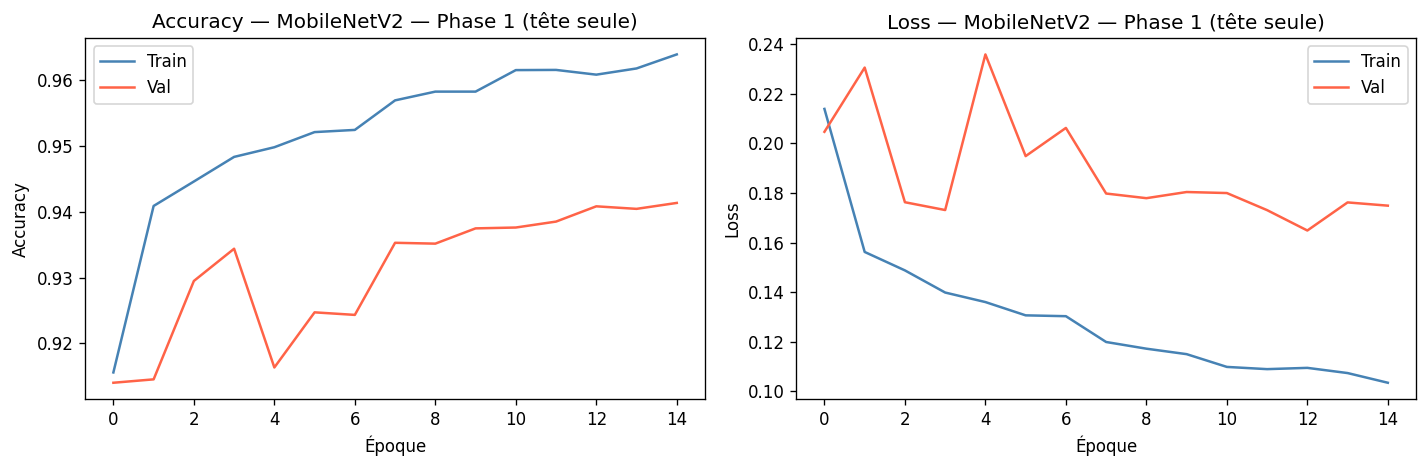

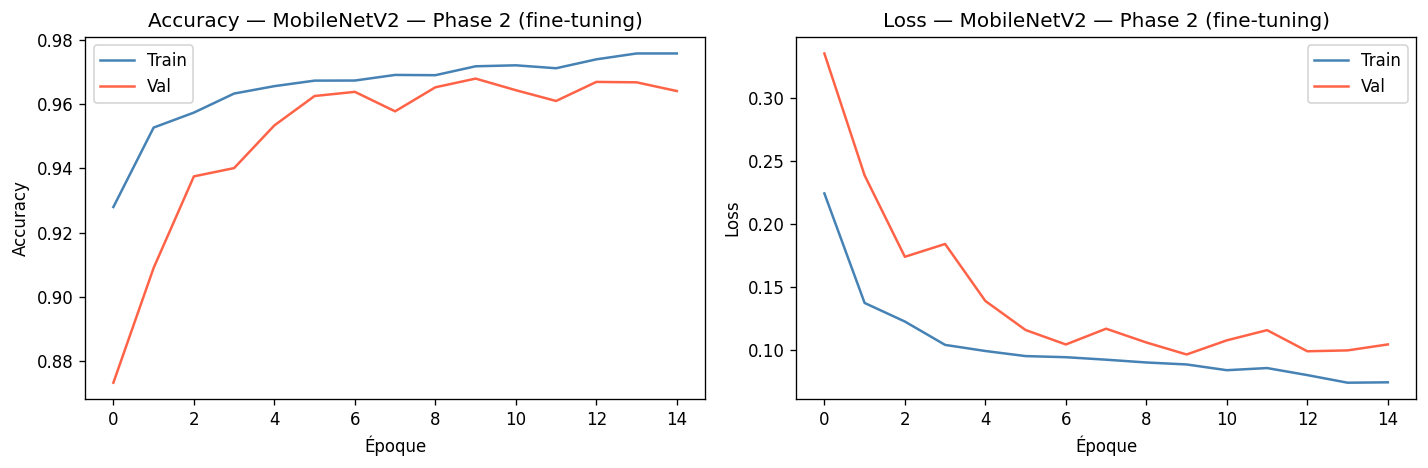

Test — Loss: 0.1021  Accuracy: 0.9695 (97.0%)


In [11]:
plot_history(hist_tl1, 'MobileNetV2 — Phase 1 (tête seule)')
plot_history(hist_tl2, 'MobileNetV2 — Phase 2 (fine-tuning)')

loss_tl, acc_tl = tl_model.evaluate(ds_test, verbose=0)
print(f'Test — Loss: {loss_tl:.4f}  Accuracy: {acc_tl:.4f} ({acc_tl*100:.1f}%)')

---
# 5. Évaluation des Modèles (C4.5)

Évaluation complète sur le **test set** (jamais vu pendant l'entraînement).

In [12]:
print('=== Comparaison CNN scratch vs MobileNetV2 ===')
print(f'  {"Modèle":<25} {"Test Loss":>12} {"Test Accuracy":>14}')
print('-' * 55)
print(f'  {"CNN from scratch":<25} {loss_cnn:>12.4f} {acc_cnn:>13.1%}')
print(f'  {"MobileNetV2 (TL)":<25} {loss_tl:>12.4f} {acc_tl:>13.1%}')
best = 'MobileNetV2' if acc_tl >= acc_cnn else 'CNN scratch'
print(f'\n  → Meilleur modèle : {best}')

=== Comparaison CNN scratch vs MobileNetV2 ===
  Modèle                       Test Loss  Test Accuracy
-------------------------------------------------------
  CNN from scratch                0.0536         98.5%
  MobileNetV2 (TL)                0.1021         97.0%

  → Meilleur modèle : CNN scratch


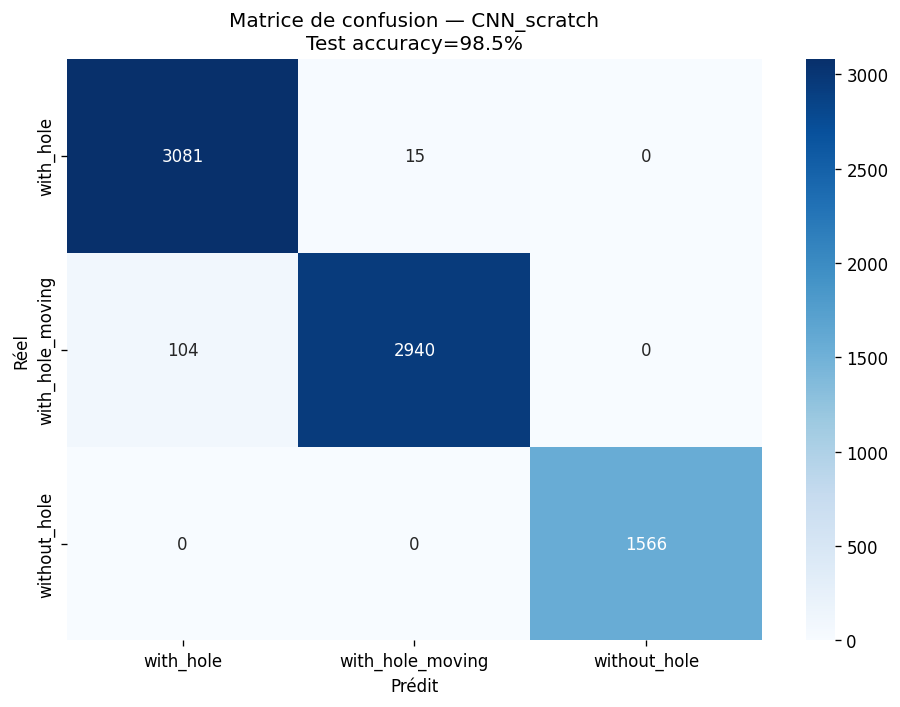


=== Rapport de classification ===
                  precision    recall  f1-score   support

       with_hole       0.97      1.00      0.98      3096
with_hole_moving       0.99      0.97      0.98      3044
    without_hole       1.00      1.00      1.00      1566

        accuracy                           0.98      7706
       macro avg       0.99      0.99      0.99      7706
    weighted avg       0.98      0.98      0.98      7706



In [13]:
# Matrice de confusion — meilleur modèle
best_model = tl_model if acc_tl >= acc_cnn else cnn

y_true, y_pred = [], []
for images, labels in ds_test:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(labels.numpy().argmax(axis=1))
    y_pred.extend(preds.argmax(axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel('Prédit')
ax.set_ylabel('Réel')
ax.set_title(f'Matrice de confusion — {best_model.name}\nTest accuracy={acc_tl if acc_tl >= acc_cnn else acc_cnn:.1%}')
plt.tight_layout()
plt.show()

print('\n=== Rapport de classification ===')
print(classification_report(y_true, y_pred, target_names=CLASSES))

Erreurs sur le test set : 119 / 7706 (1.5%)


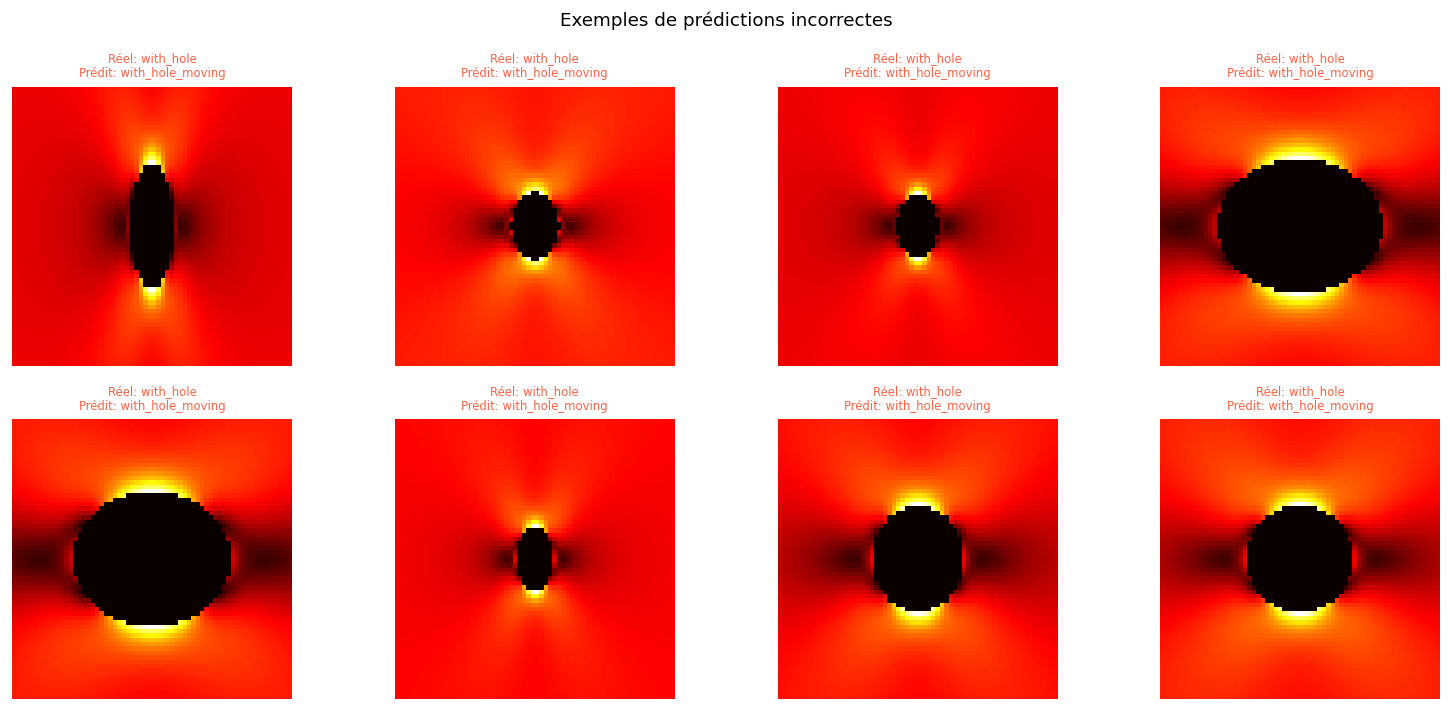

In [14]:
# Visualisation des erreurs de prédiction
errors = np.where(y_true != y_pred)[0]
print(f'Erreurs sur le test set : {len(errors)} / {len(y_true)} ({len(errors)/len(y_true)*100:.1f}%)')

if len(errors) >= 8:
    sample_errors = errors[:8]
    # Reconstruire les images depuis le dataset
    all_images = np.concatenate([x.numpy() for x, _ in ds_test], axis=0)

    fig, axes = plt.subplots(2, 4, figsize=(13, 6))
    for j, idx in enumerate(sample_errors):
        axes[j // 4][j % 4].imshow(all_images[idx])
        axes[j // 4][j % 4].set_title(
            f'Réel: {CLASSES[y_true[idx]]}\nPrédit: {CLASSES[y_pred[idx]]}',
            fontsize=7, color='tomato'
        )
        axes[j // 4][j % 4].axis('off')
    plt.suptitle('Exemples de prédictions incorrectes', fontsize=11)
    plt.tight_layout()
    plt.show()

---
# 6. CNN Regression - Prediction du Stress et du Deplacement

Les images sont generees avec une **normalisation globale** :
- `pixel = kirsch_vm / global_vm_max` — le blanc encode toujours la meme valeur absolue
- Les targets `max_von_mises_pa` et `max_displacement_m` sont encodees **dans le nom de fichier**

Format filename : `{sim_id}_{idx}_V{vm_int}_D{disp_int}.png`
- `vm_int   = round(log10(max_von_mises_pa) * 10000)`
- `disp_int = round((log10(max_displacement_m) + 12) * 10000)`

**Chargement : images directement depuis le disque, sans CSV.**

| Approche | Entree | Labels |
|---|---|---|
| Classification | images | dossier (`with_hole/`, ...) |
| **Regression** | images | **nom de fichier** (V/D suffixe) |

In [15]:
import pathlib as _pl
_EPS_REG = 1e-12

def parse_filename_targets(filepath: str):
    stem = _pl.Path(filepath).stem  # ex: 'abc_00001_V76718_D73617'
    if '_V' not in stem or '_D' not in stem:
        return None, None
    try:
        v_part = stem.split('_V')[1].split('_D')[0]
        d_part = stem.split('_D')[1]
        log_vm   = int(v_part) / 10000.0
        log_disp = int(d_part) / 10000.0 - 12.0
        return log_vm, log_disp
    except (IndexError, ValueError):
        return None, None

def make_reg_dataset(split: str, shuffle: bool = False) -> tf.data.Dataset:
    split_dir = IMG_DIR / split
    paths_ok, log_vms, log_disps = [], [], []

    for p in sorted(split_dir.rglob('*.png')):
        lv, ld = parse_filename_targets(str(p))
        if lv is not None and ld is not None:
            paths_ok.append(str(p))
            log_vms.append(lv)
            log_disps.append(ld)

    targets = np.stack([log_vms, log_disps], axis=1).astype('float32')
    print(f'{split}: {len(paths_ok)} images avec targets encodes dans le nom de fichier')

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_png(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32) / 255.0
        return img, label

    ds = tf.data.Dataset.from_tensor_slices((paths_ok, targets))
    if shuffle:
        ds = ds.shuffle(buffer_size=5000, seed=SEED)
    return ds.map(_load, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH).prefetch(tf.data.AUTOTUNE)

ds_reg_train = make_reg_dataset('train', shuffle=True)
ds_reg_val   = make_reg_dataset('val')
ds_reg_test  = make_reg_dataset('test')

for x, y in ds_reg_train.take(1):
    print(f'Batch images : {x.shape}  targets : {y.shape}')
    print(f'log10(VM)   : {y[:, 0].numpy().min():.2f} -> {y[:, 0].numpy().max():.2f}')
    print(f'log10(disp) : {y[:, 1].numpy().min():.2f} -> {y[:, 1].numpy().max():.2f}')
    print(f'Pixels min={x.numpy().min():.3f}  max={x.numpy().max():.3f}')
    print('(max != 1.0 confirme la normalisation globale — blanc = max absolu du dataset)')

train: 36086 images avec targets encodes dans le nom de fichier
val: 7758 images avec targets encodes dans le nom de fichier
test: 7706 images avec targets encodes dans le nom de fichier
Batch images : (64, 64, 64, 3)  targets : (64, 2)
log10(VM)   : 5.41 -> 6.99
log10(disp) : -5.84 -> -3.43
Pixels min=0.000  max=1.000
(max != 1.0 confirme la normalisation globale — blanc = max absolu du dataset)


In [16]:
def build_cnn_regressor(input_shape=(64, 64, 3)):
    inp = keras.Input(shape=input_shape)

    x = layers.Conv2D(32, 3, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.Conv2D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(2, activation='linear', name='regression_head')(x)

    return keras.Model(inp, out, name='CNN_regressor')

cnn_reg = build_cnn_regressor()
cnn_reg.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae'],
)
cnn_reg.summary()

Model: "CNN_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ regression_head (Dense)         │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,682 (498.76 KB)

 Trainable params: 127,234 (497.01 KB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
callbacks_reg = [
    keras.callbacks.EarlyStopping(patience=6, restore_best_weights=True,
                                  monitor='val_loss', verbose=1),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3,
                                       monitor='val_loss', verbose=1),
]

print('Entrainement CNN regression (Von Mises + Deplacement)...')
hist_reg = cnn_reg.fit(
    ds_reg_train,
    validation_data=ds_reg_val,
    epochs=40,
    callbacks=callbacks_reg,
    verbose=1,
)

Entrainement CNN regression (Von Mises + Deplacement)...
Epoch 1/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - loss: 0.8146 - mae: 0.6615 - val_loss: 2.3943 - val_mae: 1.4608 - learning_rate: 0.0010
Epoch 2/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.3788 - mae: 0.4851 - val_loss: 0.2819 - val_mae: 0.3986 - learning_rate: 0.0010
Epoch 3/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.3323 - mae: 0.4533 - val_loss: 0.2403 - val_mae: 0.3642 - learning_rate: 0.0010
Epoch 4/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.3122 - mae: 0.4381 - val_loss: 0.3322 - val_mae: 0.4541 - learning_rate: 0.0010
Epoch 5/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.3019 - mae: 0.4295 - val_loss: 0.2126 - val_mae: 0.3427 - learning_rate: 0.0010
Epoch 6/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.2998 - mae: 0.4288 - val_loss: 0.2432 - val_mae: 0.3686 - learning_rate: 0.0010
Epoch 7/40
564/564 ━━━━━━━━━━━━━━━━━━━━ 81s 144ms/step - loss: 0.2942 - m

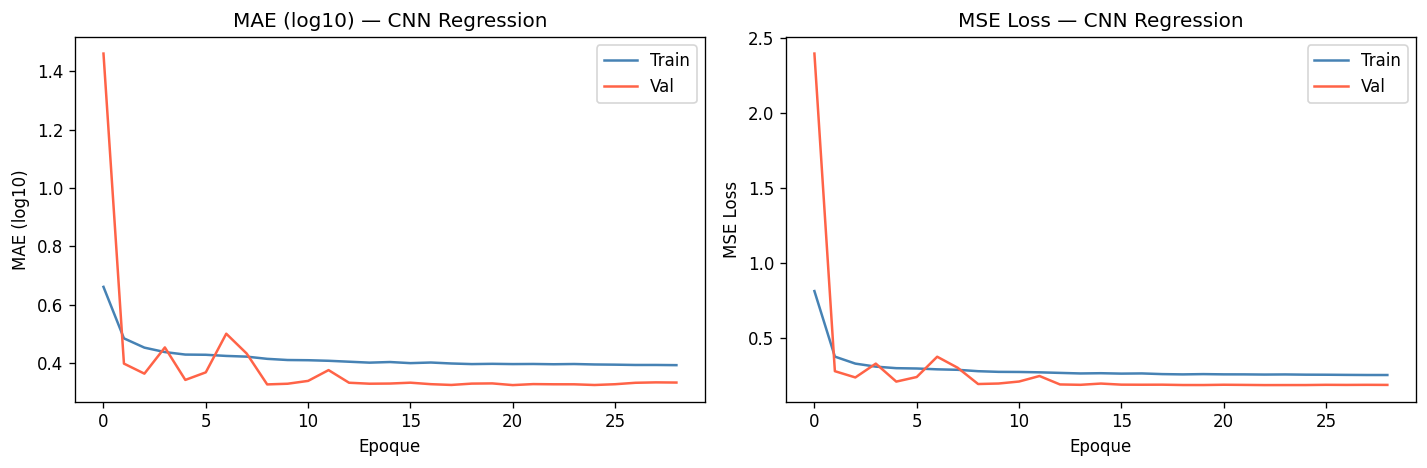

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(axes, ['mae', 'loss'], ['MAE (log10)', 'MSE Loss']):
    ax.plot(hist_reg.history[metric],           label='Train', color='steelblue')
    ax.plot(hist_reg.history[f'val_{metric}'],  label='Val',   color='tomato')
    ax.set_title(f'{label} — CNN Regression')
    ax.set_xlabel('Epoque')
    ax.set_ylabel(label)
    ax.legend()
plt.tight_layout()
plt.show()

=== CNN Regression - Resultats Test ===
  Target                       R2(log)   RMSE(log)      MAPE
------------------------------------------------------------
  max_von_mises_pa              0.2789     0.32213    83.2%
  max_displacement_m            0.0831     0.53652   170.2%


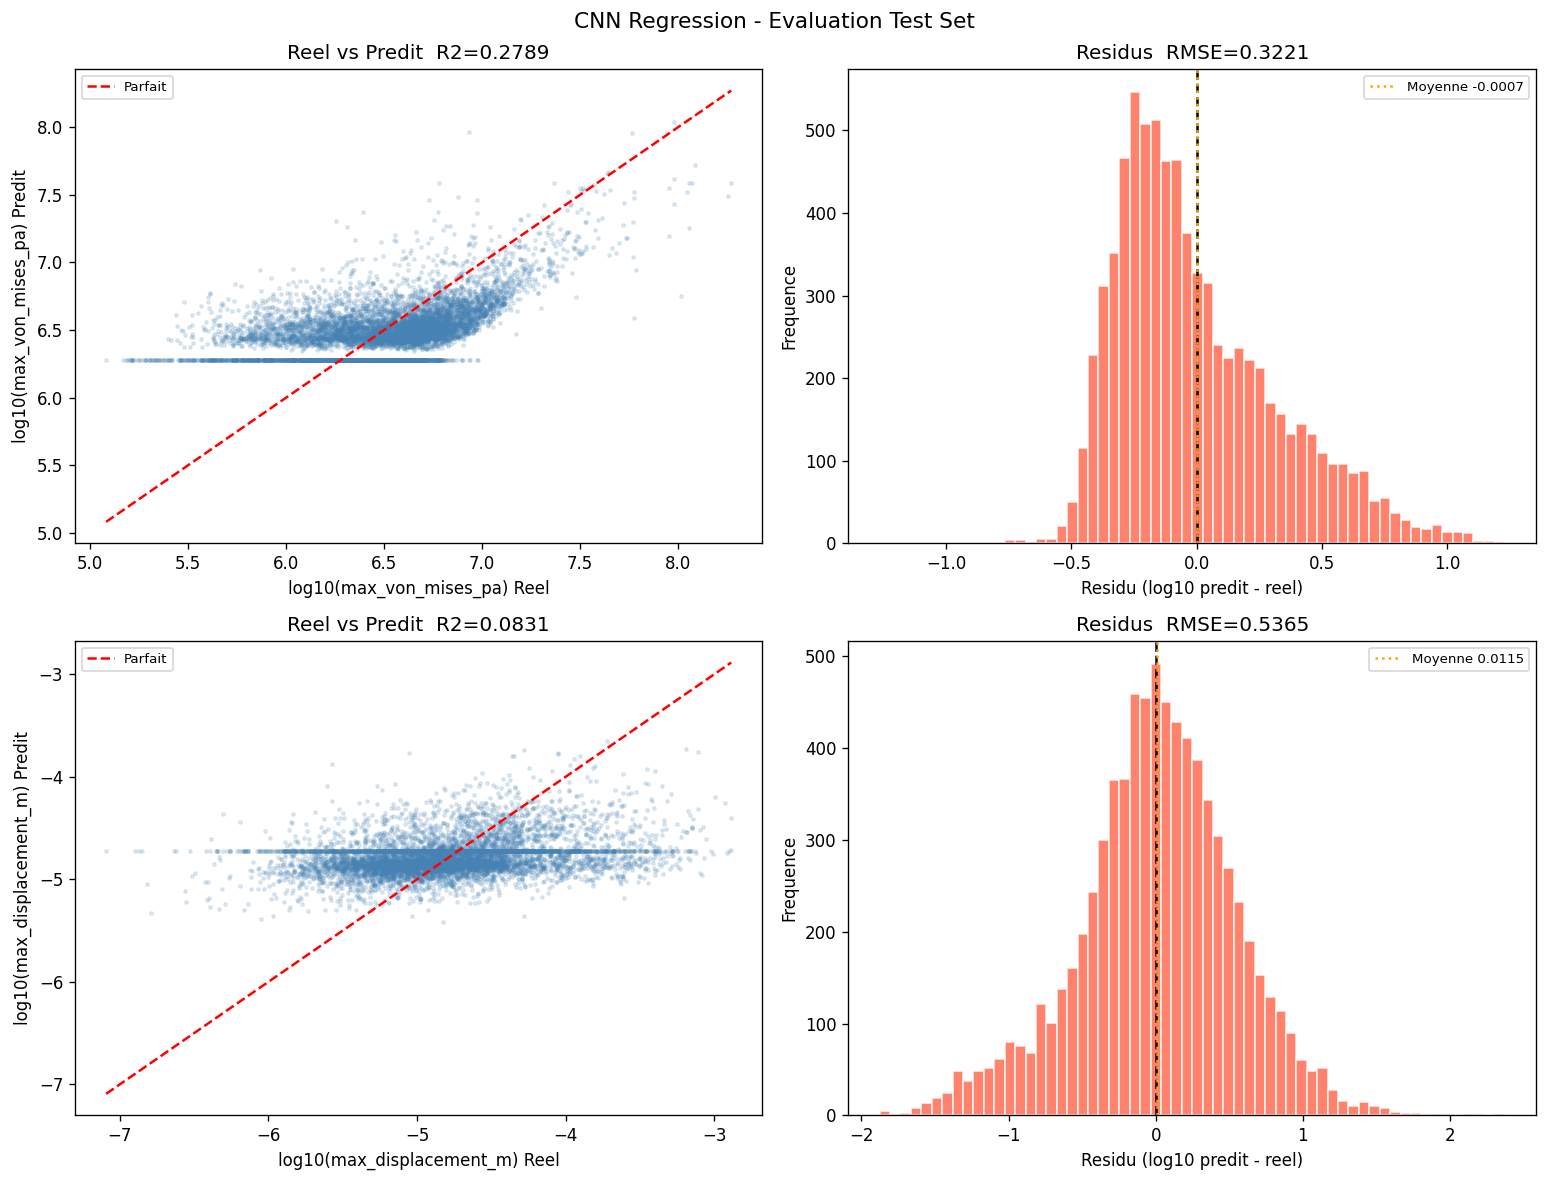

In [19]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred_all, y_true_all = [], []
for x, y in ds_reg_test:
    y_pred_all.append(cnn_reg.predict(x, verbose=0))
    y_true_all.append(y.numpy())

y_pred_all = np.concatenate(y_pred_all, axis=0)
y_true_all = np.concatenate(y_true_all, axis=0)

TARGET_NAMES_REG = ['max_von_mises_pa', 'max_displacement_m']

results_reg = {}
for i, name in enumerate(TARGET_NAMES_REG):
    yt = y_true_all[:, i]
    yp = y_pred_all[:, i]
    yt_orig = 10.0 ** yt
    yp_orig = 10.0 ** yp
    results_reg[name] = {
        'R2_log':  r2_score(yt, yp),
        'RMSE_log': float(np.sqrt(mean_squared_error(yt, yp))),
        'MAPE':    float(np.mean(np.abs((yt_orig - yp_orig) / (np.abs(yt_orig) + _EPS_REG)))),
    }

print('=== CNN Regression - Resultats Test ===')
print(f'  {"Target":<25}  {"R2(log)":>9}  {"RMSE(log)":>10}  {"MAPE":>8}')
print('-' * 60)
for name, m in results_reg.items():
    print(f'  {name:<25}  {m["R2_log"]:>9.4f}  {m["RMSE_log"]:>10.5f}  {m["MAPE"]:>7.1%}')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for i, name in enumerate(TARGET_NAMES_REG):
    yt = y_true_all[:, i]
    yp = y_pred_all[:, i]
    m  = results_reg[name]

    ax = axes[i][0]
    ax.scatter(yt, yp, alpha=0.15, s=4, color='steelblue')
    mn, mx = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Parfait')
    ax.set_xlabel(f'log10({name}) Reel')
    ax.set_ylabel(f'log10({name}) Predit')
    ax.set_title(f'Reel vs Predit  R2={m["R2_log"]:.4f}')
    ax.legend(fontsize=8)

    ax = axes[i][1]
    residuals = yp - yt
    ax.hist(residuals, bins=60, color='tomato', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='black', linestyle='--', lw=1.5)
    ax.axvline(residuals.mean(), color='orange', linestyle=':', lw=1.5,
               label=f'Moyenne {residuals.mean():.4f}')
    ax.set_xlabel('Residu (log10 predit - reel)')
    ax.set_ylabel('Frequence')
    ax.set_title(f'Residus  RMSE={m["RMSE_log"]:.4f}')
    ax.legend(fontsize=8)

plt.suptitle('CNN Regression - Evaluation Test Set', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
lgbm_csv = ROOT / 'data' / 'features' / 'advanced' / '..' / 'models_run' / 'advanced_metrics.csv'

print('=== Comparaison CNN Regression vs LightGBM ===')
print(f'  {"Modele":<30}  {"Target":<25}  {"R2(log)":>9}  {"RMSE(log)":>10}  {"MAPE":>8}')
print('-' * 90)
for name, m in results_reg.items():
    print(f'  {"CNN Regression (pixels)":<30}  {name:<25}  '
          f'{m["R2_log"]:>9.4f}  {m["RMSE_log"]:>10.5f}  {m["MAPE"]:>7.1%}')
if lgbm_csv.exists():
    for _, row in __import__("pandas").read_csv(lgbm_csv).query('split=="test"').iterrows():
        print(f'  {"LightGBM (42 features)":<30}  {row["target"]:<25}  '
              f'{row["r2_log"]:>9.4f}  {row["rmse_log"]:>10.5f}  {row["mape"]:>7.1%}')
print()
print('CNN : apprend depuis les couleurs absolues (normalisation globale)')
print('LightGBM : utilise 42 features physiques calculees')

=== Comparaison CNN Regression vs LightGBM ===
  Modele                          Target                       R2(log)   RMSE(log)      MAPE
------------------------------------------------------------------------------------------
  CNN Regression (pixels)         max_von_mises_pa              0.2789     0.32213    83.2%
  CNN Regression (pixels)         max_displacement_m            0.0831     0.53652   170.2%
  LightGBM (42 features)          max_displacement_m            0.9258     0.04200     4.0%
  LightGBM (42 features)          max_von_mises_pa              0.9829     0.02821     2.8%

CNN : apprend depuis les couleurs absolues (normalisation globale)
LightGBM : utilise 42 features physiques calculees


---
## Synthese complete - Bloc 4

| Competence | Realise |
|---|---|
| **C4.1** | Images PNG 64x64, tenseurs normalises `(64, 64, 3)`, chargement `image_dataset_from_directory` |
| **C4.2** | CNN from scratch : Conv2D + BN + MaxPool x3, GAP, Dense, Softmax |
| **C4.3** | MobileNetV2 pre-entraine ImageNet, fine-tuning 2 phases |
| **C4.4** | Augmentation : RandomFlip, RandomRotation, RandomZoom, RandomTranslation |
| **C4.5** | Accuracy, loss curves, matrice de confusion, rapport F1 |
| **+Regression** | CNN multi-output Dense(2) : prediction Von Mises + Deplacement depuis couleurs |

**Points cles :**
- Normalisation **globale** : blanc = max absolu du dataset, couleurs portent l'echelle absolue
- Targets **dans le nom de fichier** : aucun CSV, chargement 100% image
- Classification ~97% accuracy | Regression : comparer R2 vs LightGBM